# Exercise: Pyomo.DoE

In this notebook, you will use Pyomo.DoE to compute the A- and D-optimal experiments from the TCLab. In our [previous notebook](../notebooks/doe_optimize.ipynb), we used the sine test as a starting point. In this notebook, we will use the step test as the starting point.

Recall, we can computing the next best experiment assuming we already completed one prior experiment. Thus it is important to confirm our optimal experiment design does not change if we change the prior experiment of optimization initial point.

In [1]:
import sys

# If running on Google Colab, install Pyomo and Ipopt via IDAES
on_colab = "google.colab" in sys.modules
if on_colab:
    !wget "https://raw.githubusercontent.com/dowlinglab/pyomo-doe/main/notebooks/tclab_pyomo.py"
else:
    import os

    if "exercise_solutions" in os.getcwd():
        # Add the "notebooks" folder to the path
        # This is needed for running the solutions from a separate folder
        # You only need this if you run locally
        sys.path.append('../notebooks')

# import TCLab model, simulation, and data analysis functions
from tclab_pyomo import (
    TC_Lab_data,
    TC_Lab_experiment,
    extract_results,
    extract_plot_results,
    results_summary,
)

# set default number of states in the TCLab model
number_tclab_states = 2

## Load and explore experimental data (step test)

We will load the step test experimental data, similar to our previous notebooks.

In [2]:
import pandas as pd

if on_colab:
    file = "https://raw.githubusercontent.com/dowlinglab/pyomo-doe/main/data/tclab_step_test.csv"
else:
    file = '../data/tclab_step_test.csv'
df = pd.read_csv(file)
df.head()

,Time,T1,T2,Q1,Q2
0,0.00,22.84,22.84,50.0,0.0
1,1.00,22.84,22.84,50.0,0.0
2,2.01,23.16,22.84,50.0,0.0
3,3.02,22.84,22.84,50.0,0.0
4,4.01,22.84,22.84,50.0,0.0


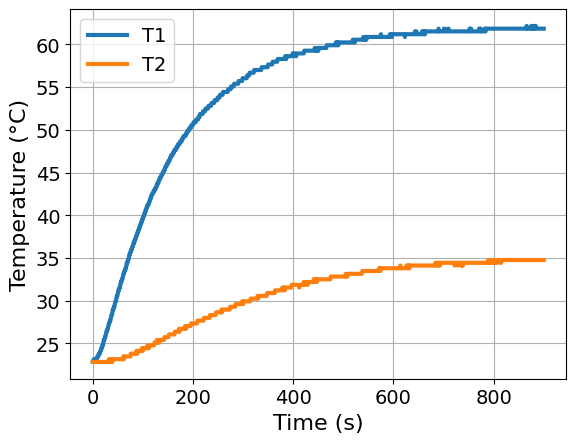

In [3]:
ax = df.plot(x='Time', y=['T1', 'T2'], xlabel='Time (s)', ylabel='Temperature (°C)')
ax.grid(True)

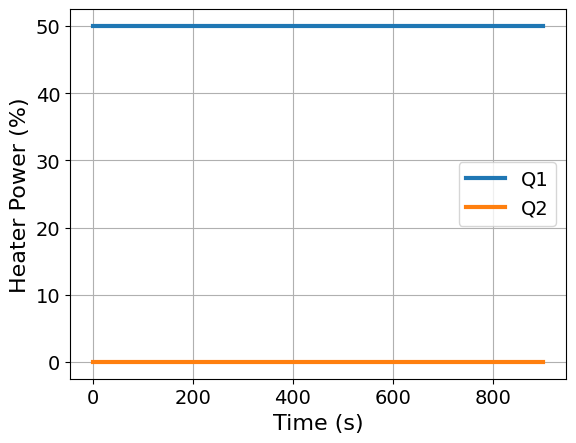

In [4]:
ax = df.plot(x='Time', y=['Q1', 'Q2'], xlabel='Time (s)', ylabel='Heater Power (%)')
ax.grid(True)

In [5]:
# Here, we will induce a step size of 10 seconds, as to not give too many 
# degrees of freedom for experimental design.
skip = 10

# Create the data object considering the new control points every 6 seconds
tc_data = TC_Lab_data(
    name="Sine Wave Test for Heater 1",
    time=df['Time'].values[::skip],
    T1=df['T1'].values[::skip],
    u1=df['Q1'].values[::skip],
    P1=200,
    TS1_data=None,
    T2=df['T2'].values[::skip],
    u2=df['Q2'].values[::skip],
    P2=200,
    TS2_data=None,
    Tamb=df['T1'].values[0],
)

## Use prior parameter information
You will use the parameter estimate and the Fisher information matrix (FIM) from previous [parmest exercise](../exercise_solutions/parmest_exercise.ipynb) notebook to pass it as the prior FIM in the `DesignOfExperiments` object.

In [6]:
import numpy as np

# Parameter values estimated from the regularized regression in the previous parmest
# exercise notebook
theta_values = {
    'beta_1': 0.0133,  # Watts/Joules
    'beta_2': 0.0216,  # Watts/Joules
    'beta_3': 0.0287,  # Watts/Joules
    'beta_4': 0.0102,  # °C.Watts/(Joules.%)
}

# Prior FIM from the notebook (FIM = covariance matrix)^(-1))
PRIOR_FIM = np.array(
    [
        [2.5458e09, -8.4425e08, 1.2854e09, 1.5849e09],
        [-8.4425e08, 3.1042e08, -4.0976e08, -5.2518e08],
        [1.2854e09, -4.0976e08, 6.5803e08, 8.0051e08],
        [1.5849e09, -5.2518e08, 8.0051e08, 9.8675e08],
    ]
)
#Make sure it is symmetric
PRIOR_FIM = 0.5 * (PRIOR_FIM + PRIOR_FIM.T)

In [7]:
# Call our custom function to summarize the results
# and compute the eigendecomposition of the FIM
# Set `reparam=True` in this function since we are using the reparameterized model

### BEGIN SOLUTION
results_summary(PRIOR_FIM, reparam=True)
### END SOLUTION

======Results Summary======
Five design criteria log10() value:
Pseudo A-optimality: 9.653309012938479
A-optimality: -3.7180317015474027
D-optimality: 25.766913035758076
E-optimality: 3.759129284987776
Modified E-optimality: 5.890357174341751

FIM:
 [[ 2.5458e+09 -8.4425e+08  1.2854e+09  1.5849e+09]
 [-8.4425e+08  3.1042e+08 -4.0976e+08 -5.2518e+08]
 [ 1.2854e+09 -4.0976e+08  6.5803e+08  8.0051e+08]
 [ 1.5849e+09 -5.2518e+08  8.0051e+08  9.8675e+08]]

eigenvalues:
 [4.46155714e+09 3.93791714e+07 5.79469681e+04 5.74287396e+03]

Eigenvector matrix:
         eigvec_1  eigvec_2  eigvec_3  eigvec_4
beta_1    0.7554    0.0245   -0.6547    0.0137
beta_2   -0.2508    0.8710   -0.2496    0.3409
beta_3    0.3813    0.4899    0.4447   -0.6456
beta_4    0.4703    0.0279    0.5580    0.6832


## Optimize the next experiment (pseudo-A-optimality)

Now we are ready to compute the pseudo-A-optimal next best experiment. Why are we starting with pseudo-A-optimality? It runs faster so it is better for debugging syntax.

In [8]:
from pyomo.contrib.doe import DesignOfExperiments
# Create experiment object for design of experiments
### BEGIN SOLUTION
doe_experiment = TC_Lab_experiment(data=tc_data, 
                                   theta_initial=theta_values, 
                                   number_of_states=number_tclab_states, 
                                   reparam=True)
### END SOLUTION

# Create the design of experiments object using our experiment instance from above
### BEGIN SOLUTION
TC_Lab_DoE_A = DesignOfExperiments(experiment=doe_experiment, 
                                 step=1e-2,
                                 scale_constant_value=1,
                                 scale_nominal_param_value=False,
                                 objective_option="pseudo_trace",  # Now we specify a type of objective, A-opt = "trace"
                                 prior_FIM=PRIOR_FIM,  # We use the prior information from the same existing experiment as in the D-optimal case!
                                 tee=True,)
### END SOLUTION

# Run DoE analysis
### BEGIN SOLUTION
TC_Lab_DoE_A.run_doe()
### END SOLUTION

Ipopt 3.14.19: linear_solver=ma57
halt_on_ampl_error=yes
max_iter=3000


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.19, running with linear solver ma57.

Number of nonzeros in equality constraint Jacobian...:     1080
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:        0

Total number of variables............................:      362
                     variables with only lower bounds:        0
                variables with lower and upper bounds:      180
                     variables with only upper bounds:        0
Total number of equality co

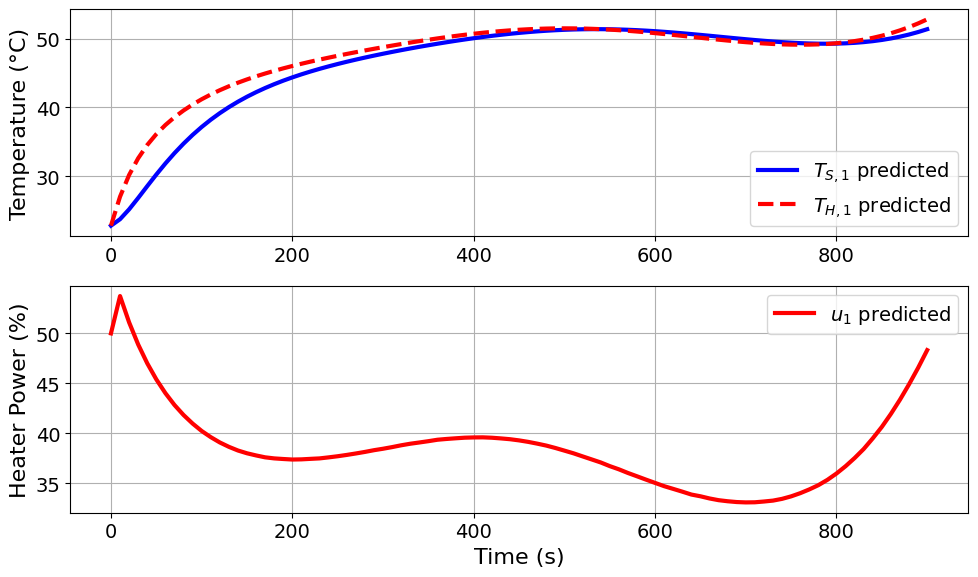

Model parameters:
Beta_1 = 0.0134 Watts/Joules
Beta_2 = 0.0216 Watts/Joules
Beta_3 = 0.0287 Watts/Joules
Beta_4 = 0.0102 °C.Watts/(Joules.%)
 


In [9]:
# Extract and plot the results using our custom function
### BEGIN SOLUTION
aopt_pyomo_doe_results = extract_plot_results(None, 
                                              TC_Lab_DoE_A.model.fd_scenario_blocks[0], 
                                              reparam=True)
### END SOLUTION

In [10]:
# Compute the FIM at the optimal solution
### BEGIN SOLUTION
results_summary(TC_Lab_DoE_A.results['FIM'])
### END SOLUTION

======Results Summary======
Five design criteria log10() value:
Pseudo A-optimality: 11.632005358058334
A-optimality: -10.42759987096037
D-optimality: 44.11920956435544
E-optimality: 11.018805407248736
Modified E-optimality: 0.025735008042659515

FIM:
 [[np.float64(108654080051.50371), np.float64(-484353370.6702911), np.float64(881698626.4321406), np.float64(-1141456362.4863272)], [np.float64(-484353370.6702911), np.float64(104857312298.45996), np.float64(-466955066.98177904), np.float64(-1080613435.8687394)], [np.float64(881698626.4321406), np.float64(-466955066.98177904), np.float64(105198555987.17754), np.float64(1472042898.0875072)], [np.float64(-1141456362.4863272), np.float64(-1080613435.8687394), np.float64(1472042898.0875072), np.float64(109843859261.10721)]]

eigenvalues:
 [1.10800167e+11 1.08797136e+11 1.04425222e+11 1.04531282e+11]

Eigenvector matrix:
          eigvec_1  eigvec_2  eigvec_3  eigvec_4
Ua        -0.3660    0.8786    0.3052   -0.0310
Ub        -0.1486   -0.2171

**Discussion:** How do these compare to our [previous A-optimal results](../notebooks/doe_optimize.ipynb) considering the sine test as the prior experiment?

## Optimize the next experiment (D-optimality)

Finally, we are ready to solve the D-optimality problem. This may take 2 minutes to run.

In [11]:
# Create experiment object for design of experiments
### BEGIN SOLUTION
doe_experiment = TC_Lab_experiment(data=tc_data, 
                                   theta_initial=theta_values, 
                                   number_of_states=number_tclab_states, 
                                   reparam=True)
### END SOLUTION

# Create the design of experiments object using our experiment instance from above
### BEGIN SOLUTION
TC_Lab_DoE_D = DesignOfExperiments(experiment=doe_experiment, 
                                 step=1e-2,
                                 scale_constant_value=1,
                                 scale_nominal_param_value=True,
                                 objective_option="determinant",  # Now we specify a type of objective, D-opt = "determinant"
                                 prior_FIM=PRIOR_FIM,  # We use the prior information from the existing experiment!
                                 tee=True,)
### END SOLUTION

### BEGIN SOLUTION
TC_Lab_DoE_D.run_doe()
### END SOLUTION

Ipopt 3.14.19: linear_solver=ma57
halt_on_ampl_error=yes
max_iter=3000


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.19, running with linear solver ma57.

Number of nonzeros in equality constraint Jacobian...:     1080
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:        0

Total number of variables............................:      362
                     variables with only lower bounds:        0
                variables with lower and upper bounds:      180
                     variables with only upper bounds:        0
Total number of equality co

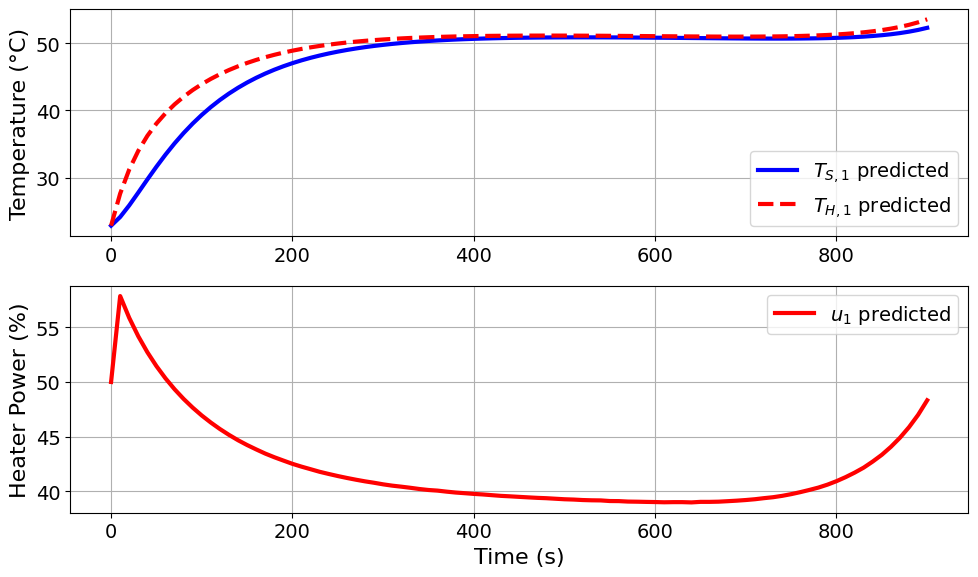

Model parameters:
Beta_1 = 0.0134 Watts/Joules
Beta_2 = 0.0216 Watts/Joules
Beta_3 = 0.0287 Watts/Joules
Beta_4 = 0.0102 °C.Watts/(Joules.%)
 


In [12]:
# Extract and plot the results using our custom function
### BEGIN SOLUTION
dopt_pyomo_doe_results = extract_plot_results(None, TC_Lab_DoE_D.model.fd_scenario_blocks[0], reparam=True)
### END SOLUTION

In [13]:
# Compute the FIM at the optimal solution
### BEGIN SOLUTION
results_summary(TC_Lab_DoE_D.results['FIM'])
### END SOLUTION

======Results Summary======
Five design criteria log10() value:
Pseudo A-optimality: 9.668505470623272
A-optimality: -6.512617987118543
D-optimality: 31.996839044871958
E-optimality: 6.56033815289899
Modified E-optimality: 3.089324079952704

FIM:
 [[np.float64(2596488339.391126), np.float64(-818506438.0512121), np.float64(1233699866.7888644), np.float64(1540258006.549339)], [np.float64(-818506438.0512121), np.float64(324632101.1146927), np.float64(-437331084.18500966), np.float64(-547115699.4061023)], [np.float64(1233699866.7888644), np.float64(-437331084.18500966), np.float64(712761562.330475), np.float64(844540077.3864824)], [np.float64(1540258006.549339), np.float64(-547115699.4061023), np.float64(844540077.3864824), np.float64(1027400993.0163842)]]

eigenvalues:
 [4.46336325e+09 1.54723855e+08 3.63360867e+06 3.95622863e+07]

Eigenvector matrix:
          eigvec_1  eigvec_2  eigvec_3  eigvec_4
Ua         0.7530   -0.6508    0.0822    0.0513
Ub        -0.2518   -0.2589   -0.2955    0

**Discussion:** How do these results compare to [our previous analysis](../notebooks/doe_exercise.ipynb)?

## Optimize the next experiment (ME-optimality)

Now we look at the modified E-optimality

In [16]:
# Create experiment object for design of experiments
### BEGIN SOLUTION
doe_experiment = TC_Lab_experiment(data=tc_data, 
                                   theta_initial=theta_values, 
                                   number_of_states=number_tclab_states, 
                                   reparam=True)
### END SOLUTION

# Create the design of experiments object using our experiment instance from above
### BEGIN SOLUTION
TC_Lab_DoE_ME = DesignOfExperiments(experiment=doe_experiment, 
                                 step=1e-2,
                                 scale_constant_value=1,
                                 scale_nominal_param_value=True,
                                 objective_option="condition_number",  # Now we specify a type of objective, ME-opt = "condition_number"
                                 prior_FIM=PRIOR_FIM,  # We use the prior information from the existing experiment!
                                 tee=True,)
### END SOLUTION

### BEGIN SOLUTION
TC_Lab_DoE_ME.use_grey_box = True # Use greybox for ME
TC_Lab_DoE_ME.run_doe()
### END SOLUTION

Ipopt 3.14.19: linear_solver=ma57
halt_on_ampl_error=yes
max_iter=3000


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.19, running with linear solver ma57.

Number of nonzeros in equality constraint Jacobian...:     1080
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:        0

Total number of variables............................:      362
                     variables with only lower bounds:        0
                variables with lower and upper bounds:      180
                     variables with only upper bounds:        0
Total number of equality co

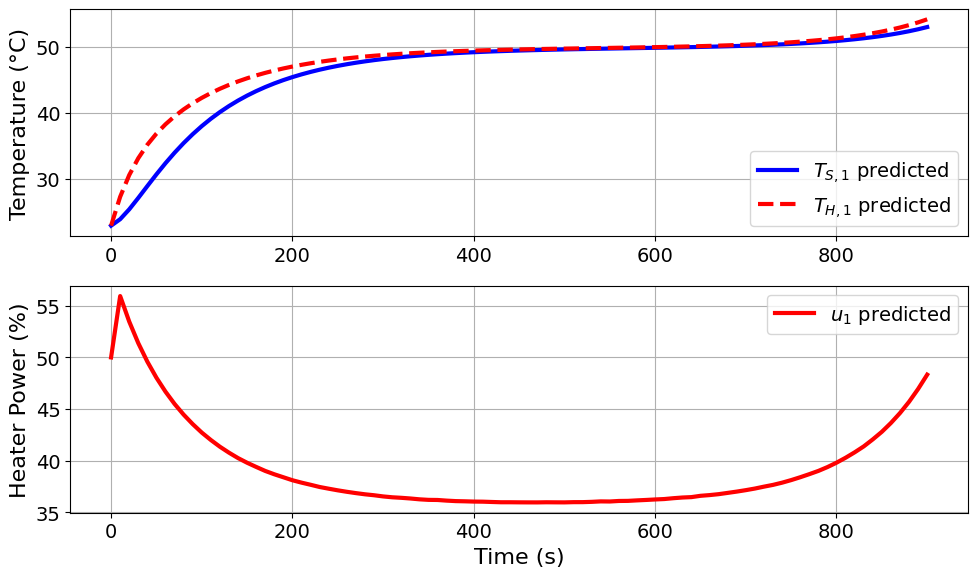

Model parameters:
Beta_1 = 0.0134 Watts/Joules
Beta_2 = 0.0216 Watts/Joules
Beta_3 = 0.0287 Watts/Joules
Beta_4 = 0.0102 °C.Watts/(Joules.%)
 


In [17]:
# Extract and plot the results using our custom function
### BEGIN SOLUTION
meopt_pyomo_doe_results = extract_plot_results(None, TC_Lab_DoE_ME.model.fd_scenario_blocks[0], reparam=True)
### END SOLUTION

In [18]:
# Compute the FIM at the optimal solution
### BEGIN SOLUTION
results_summary(TC_Lab_DoE_ME.results['FIM'])
### END SOLUTION

======Results Summary======
Five design criteria log10() value:
Pseudo A-optimality: 9.653336138474565
A-optimality: -4.9309989681267625
D-optimality: 27.710712913838353
E-optimality: 5.2329768479414485
Modified E-optimality: 4.4165098760764865

FIM:
 [[np.float64(2545845101.1273804), np.float64(-844235021.8776467), np.float64(1285371897.7166317), np.float64(1584855824.6553128)], [np.float64(-844235021.8776467), np.float64(310448355.48168766), np.float64(-409813031.75484926), np.float64(-525157511.4112223)], [np.float64(1285371897.7166317), np.float64(-409813031.75484926), np.float64(658129515.3415972), np.float64(800468796.0717173)], [np.float64(1584855824.6553128), np.float64(-525157511.4112223), np.float64(800468796.0717173), np.float64(986858164.1354525)]]

eigenvalues:
 [4.46155986e+09 3.93792915e+07 1.70992416e+05 1.70994225e+05]

Eigenvector matrix:
          eigvec_1  eigvec_2  eigvec_3  eigvec_4
Ua        -0.7554   -0.0245   -0.6483   -0.0922
Ub         0.2508   -0.8710   -0.2

**Discussion:** How do these results compare to [our previous analysis](../notebooks/doe_exercise.ipynb)?

# Exercise: Multi-experiment design

In this section, you will use the reparameterized tc lab model which you used in the previous [parmest exercise](../exercise_solutions/parmest_exercise.ipynb) and design two experiments using `Pyomo.DoE`. The structure of the reformulated model is:
$$
\frac{dT_H}{dt} = \beta_1 (T_{\text{amb}} - T_H) + \beta_2 (T_S - T_H) + \beta_4 u(t),
$$

$$
\frac{dT_S}{dt} = \beta_3 (T_H - T_S)
$$

where
$$
\beta_1 = \frac{U_a}{C_p^H}, \quad
\beta_2 = \frac{U_b}{C_p^H}, \quad
\beta_3 = \frac{U_b}{C_p^S}, \quad
\beta_4 = \frac{\alpha P}{C_p^H}
$$

You will use `D-optimality` (determinant of the FIM) to design the two experiments.

Import necessary functions for the two-state TC Lab model

In [ ]:
import sys

# If running on Google Colab, install Pyomo and Ipopt via IDAES
on_colab = "google.colab" in sys.modules
if on_colab:
    !wget "https://raw.githubusercontent.com/dowlinglab/pyomo-doe/main/notebooks/tclab_pyomo.py"
else:
    import os

    if "exercise_solutions" in os.getcwd():
        # Add the "notebooks" folder to the path
        # This is needed for running the solutions from a separate folder
        # You only need this if you run locally
        sys.path.append('../notebooks')

# import TCLab model, simulation, and data analysis functions
from tclab_pyomo import (
    TC_Lab_data,
    TC_Lab_experiment,
    extract_plot_results,
    results_summary,
)

# set default number of states in the TCLab model
number_tclab_states = 2

## Load experimental data (sine test)
We will load the sine test experimental data to serve as an initial point. 

In [ ]:
import pandas as pd

if on_colab:
    file = "https://raw.githubusercontent.com/dowlinglab/pyomo-doe/main/data/tclab_sine_test_5min_period.csv"
else:
    file = '../data/tclab_sine_test_5min_period.csv'
df = pd.read_csv(file)
df.head()

,Time,T1,T2,Q1,Q2
0,0.00,22.2,22.2,50,0
1,1.01,22.2,22.2,51,0
2,2.01,22.2,22.2,52,0
3,3.00,22.2,22.2,53,0
4,4.01,22.2,22.2,54,0


In [ ]:
# Here, we will induce a step size of 15 seconds, as to make the optimization problem
# more tractable. You can change this value to see how it affects the results
skip = 15

# Create the data object considering the new control points
tc_data_1 = TC_Lab_data(
    name="Sine Wave Test for Heater 1",
    time=df['Time'].values[::skip],
    T1=df['T1'].values[::skip],
    u1=df['Q1'].values[::skip],
    P1=200,
    TS1_data=None,
    T2=df['T2'].values[::skip],
    u2=df['Q2'].values[::skip],
    P2=200,
    TS2_data=None,
    Tamb=df['T1'].values[0],
)

## Use prior parameter information
You will use the parameter estimate and the Fisher information matrix (FIM) from previous [parmest exercise](../exercise_solutions/parmest_exercise.ipynb) notebook to pass it as the prior FIM in the `DesignOfExperiments` object.

In [ ]:
import numpy as np

# Parameter values estimated from the regularized regression in the previous parmest
# exercise notebook
theta_values = {
    'beta_1': 0.0133,  # Watts/Joules
    'beta_2': 0.0216,  # Watts/Joules
    'beta_3': 0.0287,  # Watts/Joules
    'beta_4': 0.0102,  # °C.Watts/(Joules.%)
}

# Prior FIM from the notebook (FIM = covariance matrix)^(-1))
PRIOR_FIM = np.array(
    [
        [2.5458e09, -8.4425e08, 1.2854e09, 1.5849e09],
        [-8.4425e08, 3.1042e08, -4.0976e08, -5.2518e08],
        [1.2854e09, -4.0976e08, 6.5803e08, 8.0051e08],
        [1.5849e09, -5.2518e08, 8.0051e08, 9.8675e08],
    ]
)

In [ ]:
# Call our custom function to summarize the results
# and compute the eigendecomposition of the FIM
# Set `reparam=True` in this function since we are using the reparameterized model 

### BEGIN SOLUTION
results_summary(PRIOR_FIM, reparam=True)
### END SOLUTION

======Results Summary======
Five design criteria log10() value:
Pseudo A-optimality: 9.653309012938479
A-optimality: -3.7180317015494597
D-optimality: 25.766913035762006
E-optimality: 3.759129284988475
Modified E-optimality: 5.890357174341899

FIM:
 [[ 2.5458e+09 -8.4425e+08  1.2854e+09  1.5849e+09]
 [-8.4425e+08  3.1042e+08 -4.0976e+08 -5.2518e+08]
 [ 1.2854e+09 -4.0976e+08  6.5803e+08  8.0051e+08]
 [ 1.5849e+09 -5.2518e+08  8.0051e+08  9.8675e+08]]

eigenvalues:
 [4.46155714e+09 3.93791714e+07 5.79469681e+04 5.74287396e+03]

Eigenvector matrix:
         eigvec_1  eigvec_2  eigvec_3  eigvec_4
beta_1    0.7554    0.0245   -0.6547    0.0137
beta_2   -0.2508    0.8710   -0.2496    0.3409
beta_3    0.3813    0.4899    0.4447   -0.6456
beta_4    0.4703    0.0279    0.5580    0.6832


**Discussion:** How does this FIM compare to the sine test experiment we [previously analyzed](../notebooks/doe_exploratory_analysis.ipynb)?

## Initialize two experiments
You need to create two experiment objects. The first one uses the measured sine-test data which you have already created, and the second uses a different initial input profile so that the optimizer can optimize both experiments simultaneously.

In [ ]:
# Experiment object 1
# Create experiment object for design of experiments and set reparam=True to use the
# reparameterized version of the model
### BEGIN SOLUTION
doe_experiment_1 = TC_Lab_experiment(
    data=tc_data_1,
    theta_initial=theta_values,
    number_of_states=number_tclab_states,
    reparam=True,
)
### END SOLUTION

In [ ]:
from dataclasses import replace
# Experiment object 2
# Choose between "normal" or "uniform" distribution for the new design of u1
### BEGIN SOLUTION
SEED: int = 11  # Choose any integer seed you like
PDF = "normal"  

def get_initial_u1_design(PDF="uniform", seed=11, sample_data=tc_data_1):
    rng = np.random.default_rng(seed=seed)
    if PDF == "normal":
        u1_design = rng.normal(loc=50.0, scale=10.0, size=len(sample_data.time))
        # Normal distribution is unbounded, so we need to clip the values to be within the
        # bounds of the control input, which is [0, 100] in this case.
        u1_design = np.clip(u1_design, 0.0, 100.0)
    elif PDF == "uniform":
        u1_design = rng.uniform(low=0.0, high=100.0, size=len(sample_data.time))

    # To break permutation symmetry, we can enforce that the first value of u1_design
    # is greater than the first value of the original u1 data.
    if u1_design[0] <= sample_data.u1[0] and sample_data.u1[0] < 90.0:
        u1_design[0] = sample_data.u1[0] + 10.0
    else:
        u1_design[0] = 100.0

    # Create a new data object with only u1 replaced
    tc_data_new = replace(sample_data, u1=u1_design)
    return tc_data_new

tc_data_2 = get_initial_u1_design(PDF=PDF, seed=SEED, sample_data=tc_data_1)
### END SOLUTION
# Build the experiment 2 with the new design variable and set reparam=True
### BEGIN SOLUTION
doe_experiment_2 = TC_Lab_experiment(
    data=tc_data_2,
    theta_initial=theta_values,
    number_of_states=number_tclab_states,
    reparam=True,
)
### END SOLUTION

## Optimize two experiments (D-optimality)
Now, you create a `DesignOfExperiments` object for the two experiments and choose a D-optimality ("determinant") objective. You also pass prior_FIM, which represents information already available from previous parameter estimation.

In [ ]:
# Add a solver object to pass to DesignOfExperiments
### BEGIN SOLUTION
from pyomo.environ import SolverFactory
solver = SolverFactory("ipopt")
solver.options["max_iter"] = 3000
solver.options["tol"] = 1e-6
solver.options["linear_solver"] = "ma57"
solver.options["nlp_scaling_method"] = "gradient-based"
solver.options["mu_strategy"] = "adaptive"
### END SOLUTION

In [ ]:
# Load Pyomo.DoE class
from pyomo.contrib.doe import DesignOfExperiments

# Create the `DesignOfExperiments` object using your experiment instances from above
### BEGIN SOLUTION
SCALE_BY_NOMINAL_PARAM = False
TC_Lab_DoE_D = DesignOfExperiments(
    experiment=[doe_experiment_1, doe_experiment_2],
    # We are optimizing two experiments simultaneously!
    step=1e-2,
    scale_constant_value=1,
    scale_nominal_param_value=SCALE_BY_NOMINAL_PARAM,
    objective_option="determinant",
    # Now we specify a type of objective, D-opt = "determinant"
    prior_FIM=PRIOR_FIM,
    tee=True,
    solver=solver,
)
### END SOLUTION

In [ ]:
# Optimize two experiments simultaneously
### BEGIN SOLUTION
TC_Lab_DoE_D.optimize_experiments()
### END SOLUTION

Ipopt 3.13.2: max_iter=3000
tol=1e-06
linear_solver=ma57
nlp_scaling_method=gradient-based
mu_strategy=adaptive


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
    

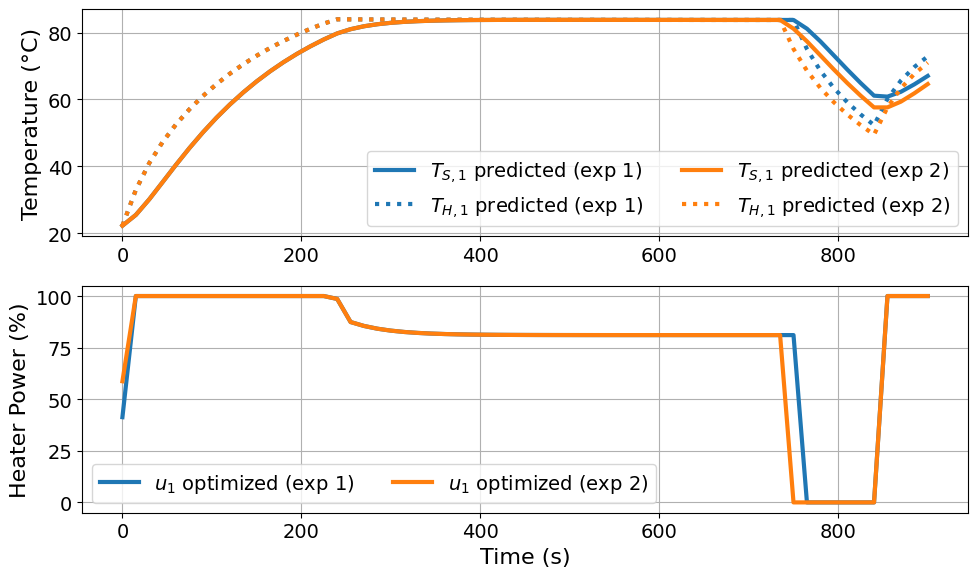

In [ ]:
# Extract and plot the results using our custom function
### BEGIN SOLUTION
multiexp_results = extract_plot_results(None, TC_Lab_DoE_D)
###

In [ ]:
# Extract the FIM and compute the results summary at the optimal solution
### BEGIN SOLUTION
FIM_D = np.asarray(TC_Lab_DoE_D.results["solution"]["param_scenarios"][0]['total_fim'])
results_summary(np.asarray(FIM_D))
### END SOLUTION

======Results Summary======
Five design criteria log10() value:
Pseudo A-optimality: 10.923662526066758
A-optimality: -4.336346647519421
D-optimality: 32.60343334101462
E-optimality: 4.336571095847328
Modified E-optimality: 6.556955853647287

FIM:
 [[ 2.77967675e+10 -1.44462418e+08  5.98127129e+08 -3.43281307e+10]
 [-1.44462418e+08  4.32023332e+08 -5.60245908e+08 -2.04462580e+09]
 [ 5.98127129e+08 -5.60245908e+08  8.51842255e+08  2.46915999e+09]
 [-3.43281307e+10 -2.04462580e+09  2.46915999e+09  5.48001596e+10]]

eigenvalues:
 [7.82576765e+10 5.58076514e+09 2.17055650e+04 4.23293451e+07]

Eigenvector matrix:
          eigvec_1  eigvec_2  eigvec_3  eigvec_4
Ua         0.5620   -0.7429   -0.3624   -0.0298
Ub         0.0208    0.2561   -0.4210   -0.8699
inv_CpH   -0.0222   -0.3794    0.7836   -0.4914
inv_CpS   -0.8266   -0.4885   -0.2781   -0.0290


In [ ]:
# Create a helper function to compute FIM metrics
### BEGIN SOLUTION
def log10_FIM_metric(FIM):
    pseudo_A_opt = np.log10(np.trace(FIM))
    A_opt = np.log10(np.trace(np.linalg.inv(FIM)))
    D_opt = np.log10(np.linalg.det(FIM))
    E_opt = np.log10(np.min(np.linalg.eigvals(FIM)))
    ME_opt = np.log10(np.max(np.linalg.eigvals(FIM)) / np.min(np.linalg.eigvals(FIM)))
    return pseudo_A_opt, A_opt, D_opt, E_opt, ME_opt
### END SOLUTION

In [ ]:
# Compare the how much the new experiment improved the FIM metrics compared to the prior experiment
### BEGIN SOLUTION
import pandas as pd

prior_metrics = log10_FIM_metric(PRIOR_FIM)
optimized_metrics = log10_FIM_metric(FIM_D)
metric_names = ["pseudo_A_opt", "A_opt", "D_opt", "E_opt", "ME_opt"]

metrics_df = pd.DataFrame(
    {
        "prior": list(prior_metrics),
        "optimized": list(optimized_metrics),
    },
    index=metric_names,
)
metrics_df.index.name = "metric"

metrics_df.round(2)
### END SOLUTION

,prior,optimized
metric,,
pseudo_A_opt,9.65,10.92
A_opt,-3.72,-4.34
D_opt,25.77,32.60
E_opt,3.76,4.34
ME_opt,5.89,6.56
